<a href="https://colab.research.google.com/github/Anik-Adnan/Python-AI-ML-Masterclass/blob/main/Day01_Introduction_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 01 — Introduction to Artificial Intelligence

## Objectives
By the end of this notebook you will be able to:
- Define AI, Machine Learning (ML), and Deep Learning (DL), and state precisely how they relate.
- Distinguish the major paradigms of ML: supervised, unsupervised, and reinforcement learning.
- Articulate the generic learning problem as function approximation under uncertainty.
- Identify real-world domains where each paradigm dominates.
- Set up and verify a Google Colab environment for this 30-day course.


## 1. What is Artificial Intelligence?

**Artificial Intelligence (AI)** is the field of building systems that perform tasks which, when
performed by humans, are said to require intelligence — perception, reasoning, planning, language,
and learning.

AI is best understood as **nested subfields**, not synonyms:

```
AI  ⊃  Machine Learning (ML)  ⊃  Deep Learning (DL)
```

| Layer | Defining idea | Example |
|---|---|---|
| AI | Any technique that produces intelligent behaviour, including hand-coded rules | A chess engine with hard-coded heuristics |
| ML | Systems that **learn** a mapping from data instead of being explicitly programmed | A spam filter trained on labelled emails |
| DL | ML using multi-layer neural networks to learn hierarchical feature representations | A CNN that learns edges → shapes → objects |

**Key distinction — classical programming vs. ML:**

- Classical programming: `Rules + Data → Program → Output`
- Machine Learning: `Data + Output → Algorithm → Rules (Model)`

In ML we do not write the decision logic; we write an algorithm that *discovers* the logic from
examples.


## 2. The Learning Problem — Mathematical Intuition

Almost every supervised ML problem can be written as: given a dataset of input–output pairs

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{N}, \quad x_i \in \mathbb{R}^d,\; y_i \in \mathcal{Y}
$$

we want to find a function $f_\theta : \mathbb{R}^d \to \mathcal{Y}$, parameterised by $\theta$,
that minimises an expected **loss** $\mathcal{L}$ over unseen data:

$$
\theta^{*} = \arg\min_{\theta} \; \mathbb{E}_{(x,y)\sim P}\big[\mathcal{L}(f_\theta(x), y)\big]
$$

Since the true distribution $P$ is unknown, we approximate this with the **empirical risk** over
the training set:

$$
\hat{\theta} = \arg\min_{\theta} \; \frac{1}{N}\sum_{i=1}^{N} \mathcal{L}(f_\theta(x_i), y_i)
$$

This single equation underlies linear regression, logistic regression, SVMs, random forests, and
deep neural networks — only $f_\theta$, $\mathcal{L}$, and the optimisation procedure change.

**Three paradigms** differ in what supervision is available:

1. **Supervised learning** — $y_i$ is known for every $x_i$ (classification, regression).
2. **Unsupervised learning** — only $x_i$ is known; the goal is to discover structure
   (clustering, dimensionality reduction).
3. **Reinforcement learning** — an agent learns $\pi(a|s)$ by interacting with an environment and
   receiving scalar rewards, with no direct $(x,y)$ pairs at all.


In [1]:
# Environment check — run this first in every notebook of this course.
import sys
import platform

print("Python version :", sys.version.split()[0])
print("Platform       :", platform.platform())

# Core scientific stack used throughout the course
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print("NumPy          :", np.__version__)
print("Pandas         :", pd.__version__)
print("Matplotlib     :", matplotlib.__version__)
print("scikit-learn   :", sklearn.__version__)


Python version : 3.12.13
Platform       : Linux-6.6.122+-x86_64-with-glibc2.35
NumPy          : 2.0.2
Pandas         : 2.2.2
Matplotlib     : 3.10.0
scikit-learn   : 1.6.1


## 3. A Minimal Working Example: Rule-Based vs. Learned Decision Boundary

To make the distinction concrete, we solve the *same* toy problem twice: once with a hand-written
rule (classical AI) and once by *learning* the rule from data (ML). The task: decide whether a
point $(x_1, x_2)$ lies "above" or "below" a hidden linear boundary.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Hidden ground-truth rule: label = 1 if x2 > 2*x1 + 1, else 0
N = 200
X = rng.uniform(-5, 5, size=(N, 2))
true_rule = lambda x: (x[:, 1] > 2 * x[:, 0] + 1).astype(int)
y = true_rule(X)

# --- Approach 1: Classical AI — we HAND-CODE the exact rule ---
def rule_based_classifier(x):
    return (x[:, 1] > 2 * x[:, 0] + 1).astype(int)

# --- Approach 2: Machine Learning — we LEARN the rule from (X, y) ---
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X, y)

print("Rule-based accuracy :", (rule_based_classifier(X) == y).mean())
print("Learned   accuracy :", (clf.predict(X) == y).mean())
print("\nLearned coefficients (should approximate the line x2 = 2*x1 + 1):")
print("w1, w2 =", clf.coef_[0], " bias =", clf.intercept_[0])


Rule-based accuracy : 1.0
Learned   accuracy : 0.99

Learned coefficients (should approximate the line x2 = 2*x1 + 1):
w1, w2 = [-2.88222969  1.4608658 ]  bias = -1.6285642575910544


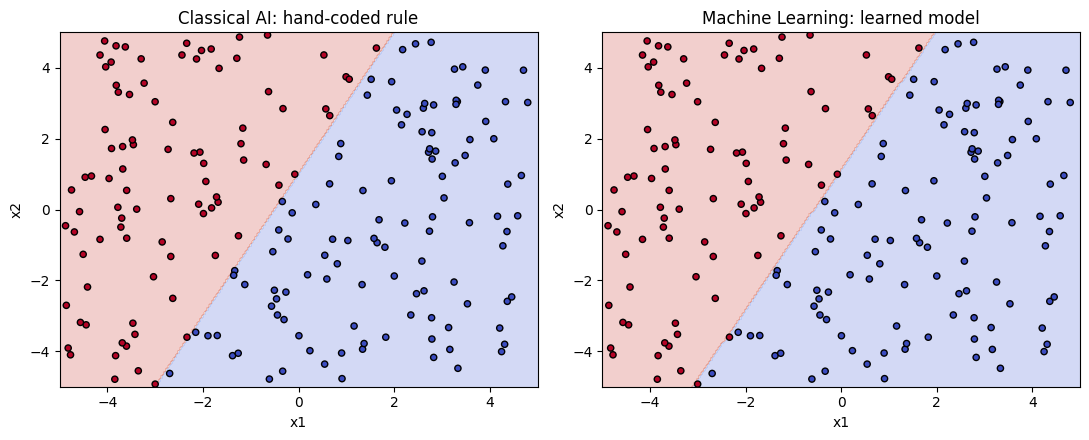

In [3]:
# Visualise both decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, Z, title in zip(
    axes,
    [rule_based_classifier(grid).reshape(xx.shape), clf.predict(grid).reshape(xx.shape)],
    ["Classical AI: hand-coded rule", "Machine Learning: learned model"],
):
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=20)
    ax.set_title(title)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")

plt.tight_layout()
plt.show()


## 4. Real-World Application Map

| Domain | Paradigm | Example System |
|---|---|---|
| Email | Supervised (classification) | Spam detection |
| Finance | Supervised (regression) | Credit-risk scoring |
| Retail | Unsupervised (clustering) | Customer segmentation |
| Robotics | Reinforcement Learning | Locomotion control |
| Vision | Deep Learning (CNN) | Autonomous driving perception |
| Language | Deep Learning (Transformers) | Chatbots, translation |

## Common Misconceptions
- **"AI = robots."** AI is a computational technique; embodiment is a separate engineering concern.
- **"More data always means better models."** Data *quality*, label correctness, and distributional
  match to the deployment setting matter as much as quantity.
- **"Deep learning is always the right tool."** For small, structured, tabular datasets, classical
  ML (trees, linear models) frequently outperforms DL and is far cheaper to train and explain.

## Summary
AI is the umbrella goal; ML is the data-driven approach to reach it; DL is ML using layered neural
networks. Every supervised algorithm we study in this course instantiates the same empirical-risk
minimisation template — what changes is the model family $f_\theta$, the loss $\mathcal{L}$, and how
$\theta$ is optimised.


## Exercises

**Practice**
1. List three AI systems you used today and classify each as rule-based, supervised ML, or DL.
2. Modify the hidden rule in the code above to `x2 > -x1 + 3` and re-run; confirm the learned model
   adapts without any code change to the classifier itself.
3. In your own words, explain why "empirical risk minimisation" is only an *approximation* to the
   true objective.
4. Give an example of a task suited to unsupervised learning and explain why labels are unavailable
   or undesirable there.
5. Why might a rule-based system outperform an ML system in a safety-critical, low-data domain?

**Challenge**
1. Increase label noise by flipping 10% of `y` at random. Retrain `LogisticRegression` and report
   how accuracy degrades. What does this reveal about the gap between *training* and *true* risk?
2. Research and write 150–200 words (own words, no copy-paste) comparing "narrow AI" vs. "general AI",
   citing one current system as an example of each (or argue none exists for general AI).
